##### 2-Period First Price Auction with Winning Bid Revealed

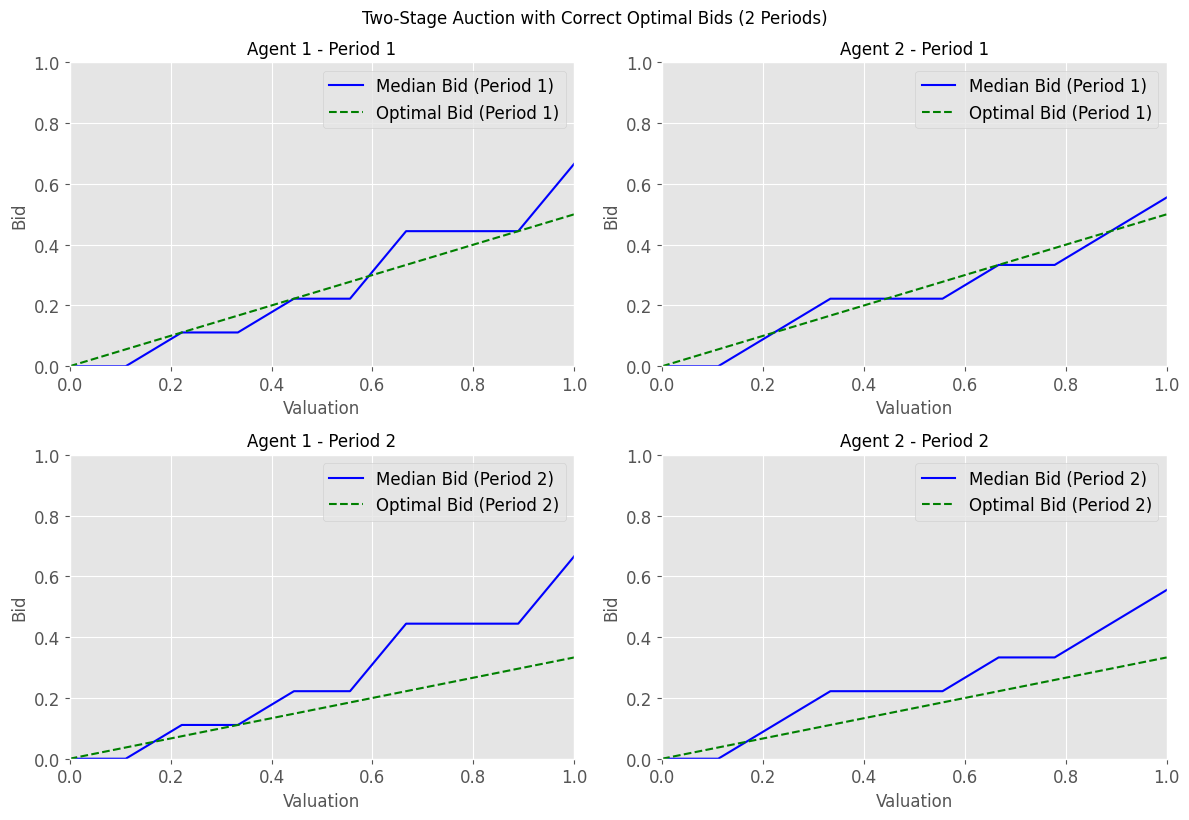

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(33454)
plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10, epsilon=0.1, alpha=0.1, min_val=0, max_val=1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))  # Q-table for the different valuation states
        self.action_counts = np.zeros((granularity, len(self.actions)))
        self.reward_history = []
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        bin_centers = np.linspace(self.min_val, self.max_val, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))

    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def choose_action(self):
        valuation_state = self.state
        return np.random.choice(self.actions) if np.random.rand() < self.epsilon else self.actions[np.argmax(self.q_values[valuation_state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)


class TwoStageAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, epsilon_reward=0.001):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.epsilon_reward = epsilon_reward
        self.profit_history = []

    def run_two_stage_auction(self):
        # Period 1
        for agent in self.agents:
            agent.refresh_valuation()
        bids_period1 = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner1_index, price1 = self.payment_rule(bids_period1)
        
        # Period 2
        bids_period2 = []
        for idx, agent in enumerate(self.agents):
            # Only using the valuation state, ignore winner/price for Q-learning agent state
            agent.state = agent.get_state(agent.valuation)  # State is only based on valuation
            bids_period2.append(max(self.price_floor, min(agent.choose_action(), self.price_ceiling)))
        winner2_index, price2 = self.payment_rule(bids_period2)

        # Update Q-values and rewards
        for idx, agent in enumerate(self.agents):
            reward1 = agent.valuation - price1 + self.epsilon_reward if idx == winner1_index else 0
            reward2 = agent.valuation - price2 + self.epsilon_reward if idx == winner2_index else 0
            agent.feedback(reward1, bids_period1[idx])
            agent.feedback(reward2, bids_period2[idx])

        self.profit_history.append((price1, price2))
        return {"winner1": winner1_index, "price1": price1, "bids1": bids_period1,
                "winner2": winner2_index, "price2": price2, "bids2": bids_period2}


def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=1000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        for _ in range(num_rounds):
            auction.run_two_stage_auction()
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles

# Updated optimal bidding rule for both periods
def optimal_bidding_rule(valuations, num_agents=2, period=1):
    if period == 1:
        return (num_agents - 1) / num_agents * valuations
    elif period == 2:
        return (num_agents - 1) / (num_agents + 1) * valuations

def plot_two_period_results(agents, percentiles, title=None, fontsize=12):
    fig, axes = plt.subplots(2, len(agents), figsize=(12, 8))  # 2 rows (for 2 periods), 2 columns (for 2 agents)
    valuations = np.linspace(0, 1, agents[0].granularity)

    for period in range(2):
        for i, agent in enumerate(agents):
            ax = axes[period, i]
            ax.fill_between(valuations, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
            ax.plot(valuations, percentiles[i]["median"], label=f'Median Bid (Period {period+1})', color='blue')
            
            # Plot the correct optimal bid for each period
            optimal_bids = optimal_bidding_rule(valuations, num_agents=len(agents), period=period+1)
            ax.plot(valuations, optimal_bids, label=f'Optimal Bid (Period {period+1})', color='green', linestyle='--')
            
            ax.set_xlim([0,1])
            ax.set_ylim([0,1])
            ax.set_xlabel('Valuation', fontsize=fontsize)
            ax.set_ylabel('Bid', fontsize=fontsize)
            ax.set_title(f'Agent {i+1} - Period {period+1}', fontsize=fontsize)
            ax.legend(fontsize=fontsize)
            ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title:
        plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()

# Running the simulation with updated optimal bids for both periods
agents = [QLearningAgent() for _ in range(2)]
auction = TwoStageAuction(agents, payment_rule=first_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=1, num_rounds=10000)
plot_two_period_results(agents, percentiles, title='Two-Stage Auction with Correct Optimal Bids (2 Periods)')


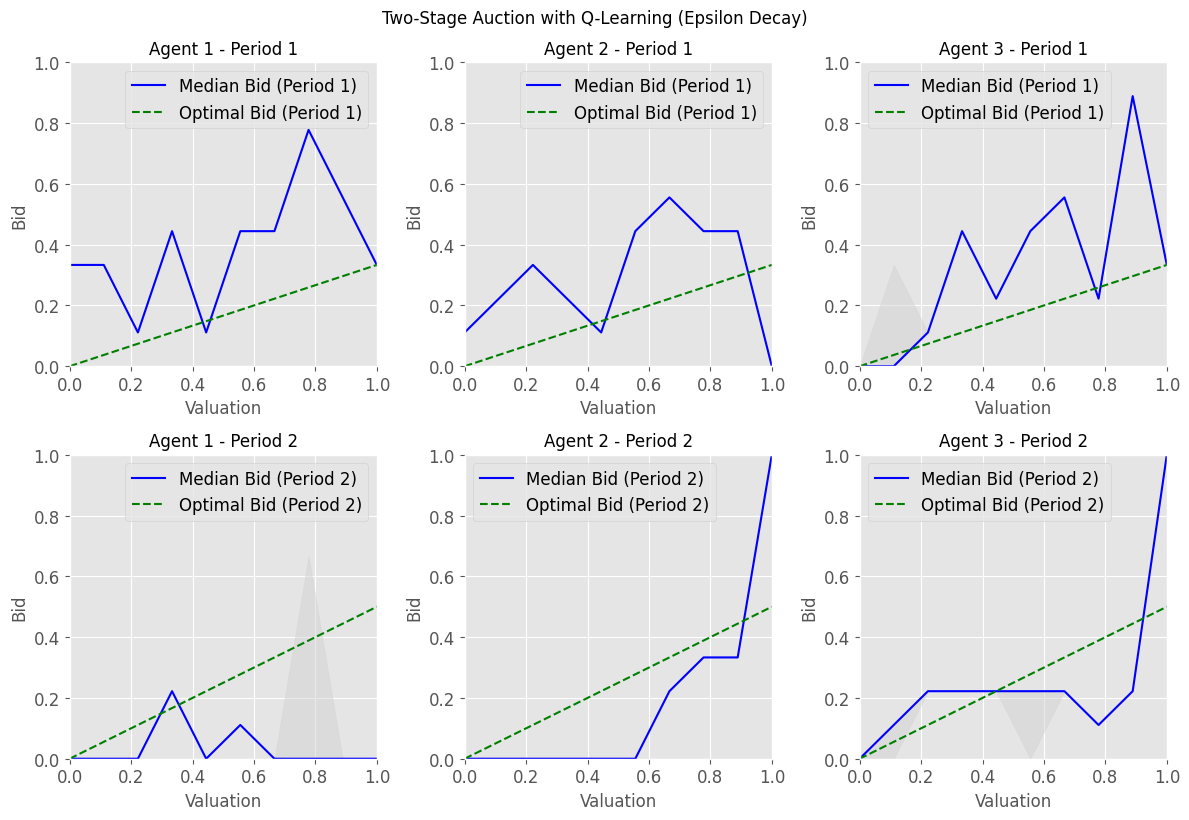

In [42]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1.0, granularity=20, epsilon=0.1, epsilon_decay=1.0, epsilon_min = 0.05, alpha=0.1, gamma=1, min_val=0, max_val=1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.alpha = alpha
        self.gamma = gamma  # Discount factor
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        self.q_values = np.random.uniform(0,1,(granularity, len(self.actions), 2))  # Q-table for states (valuation, period)
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation, period=0)
        self.won_first_round = False

    def get_state(self, valuation, period):
        valuation_state = np.digitize(valuation, np.linspace(self.min_val, self.max_val, self.granularity)) - 1
        return valuation_state, period

    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation, period=0)
        self.won_first_round = False

    def choose_action(self):
        valuation_state, period = self.state
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[valuation_state, :, period])]

    def update_q_values(self, action, reward, next_state, next_period):
        valuation_state, period = self.state
        action_index = np.argmin(np.abs(self.actions - action))
        next_valuation_state, next_period = next_state
        best_next_action_value = np.max(self.q_values[next_valuation_state, :, next_period])

        # Q-learning update rule with the discount factor
        self.q_values[valuation_state, action_index, period] += self.alpha * (
            reward + self.gamma * best_next_action_value - self.q_values[valuation_state, action_index, period]
        )

    def feedback(self, reward, action, next_state, next_period):
        self.update_q_values(action, reward, next_state, next_period)
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)

class TwoStageAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1.0, payment_rule=None, epsilon_reward=0.01):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.epsilon_reward = epsilon_reward
        self.profit_history = []

    def run_two_stage_auction(self):
        for agent in self.agents:
            agent.refresh_valuation()
    
        bids_period1 = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner1_index, price1 = self.payment_rule(bids_period1)
    
        # First round feedback
        for idx, agent in enumerate(self.agents):
            reward1 = agent.valuation - price1 + self.epsilon_reward if idx == winner1_index else 0
            next_state = agent.get_state(agent.valuation, period=1)
            agent.feedback(reward1, bids_period1[idx], next_state, 1)
            if idx == winner1_index:
                agent.won_first_round = True
    
        bids_period2 = []
        for idx, agent in enumerate(self.agents):
            agent.state = agent.get_state(agent.valuation, period=1)
            bids_period2.append(max(self.price_floor, min(agent.choose_action(), self.price_ceiling)))
    
        for idx, agent in enumerate(self.agents):
            if agent.won_first_round:
                bids_period2[idx] = -np.inf
    
        winner2_index, price2 = self.payment_rule(bids_period2)
    
        # Second round feedback
        for idx, agent in enumerate(self.agents):
            if agent.won_first_round:
                reward2 = 0
            else:
                reward2 = agent.valuation - price2 + self.epsilon_reward if idx == winner2_index else 0
            next_state = agent.get_state(agent.valuation, period=1)  # No future state after period 2
            agent.feedback(reward2, bids_period2[idx], next_state, 1)
    
        self.profit_history.append((price1, price2))
        return {"winner1": winner1_index, "price1": price1, "bids1": bids_period1,
                "winner2": winner2_index, "price2": price2, "bids2": bids_period2}
    

def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=1000, last_n_rounds=100):
    # We'll store the last N rounds bids here for each agent and each state
    recent_bids_period1 = np.zeros((last_n_rounds * num_simulations, len(agents), agents[0].granularity))
    recent_bids_period2 = np.zeros((last_n_rounds * num_simulations, len(agents), agents[0].granularity))

    row_index = 0
    for sim in range(num_simulations):
        for round_num in range(num_rounds):
            auction.run_two_stage_auction()

            # Only keep track of the last N rounds
            if round_num >= num_rounds - last_n_rounds:
                for i, agent in enumerate(agents):
                    # Store the average bids per valuation state for each period
                    avg_bids_for_valuation_period1 = [agent.actions[np.argmax(agent.q_values[state, :, 0])] for state in range(agent.granularity)]
                    avg_bids_for_valuation_period2 = [agent.actions[np.argmax(agent.q_values[state, :, 1])] for state in range(agent.granularity)]
                    
                    # Store the bids
                    recent_bids_period1[row_index, i, :] = avg_bids_for_valuation_period1
                    recent_bids_period2[row_index, i, :] = avg_bids_for_valuation_period2
                
                row_index += 1

    # Now calculate percentiles across all simulations and rounds for each agent and each period
    percentiles = {}
    for i in range(len(agents)):
        # Get all the last bids for agent i in both periods
        last_bids_for_agent_period1 = recent_bids_period1[:, i, :]
        last_bids_for_agent_period2 = recent_bids_period2[:, i, :]

        # Calculate percentiles and error bounds (5th, 50th, 95th) for each agent
        percentiles[i] = {
            "5th_period1": np.percentile(last_bids_for_agent_period1, 5, axis=0),
            "median_period1": np.median(last_bids_for_agent_period1, axis=0),
            "95th_period1": np.percentile(last_bids_for_agent_period1, 95, axis=0),
            "5th_period2": np.percentile(last_bids_for_agent_period2, 5, axis=0),
            "median_period2": np.median(last_bids_for_agent_period2, axis=0),
            "95th_period2": np.percentile(last_bids_for_agent_period2, 95, axis=0),
        }

    return percentiles



def optimal_bidding_rule(valuations, N=3, K=2, period=1):
    """Calculate the optimal bid for a given period using the formula."""
    if period == 1:
        return (N - K) / (N - 1 + 1) * valuations  # For period k=1
    elif period == 2:
        return (N - K) / (N - 2 + 1) * valuations  # For period k=2


def plot_two_period_results_with_optimal(agents, percentiles, title=None, fontsize=12):
    fig, axes = plt.subplots(2, len(agents), figsize=(12, 8))  # 2 rows (for 2 periods), 2 columns (for 2 agents)
    valuations = np.linspace(0, 1, agents[0].granularity)

    N = len(agents)
    K = 2  # For two periods as you mentioned

    for period in range(2):
        for i, agent in enumerate(agents):
            ax = axes[period, i]
            if period == 0:
                ax.fill_between(valuations, percentiles[i]["5th_period1"], percentiles[i]["95th_period1"], color='lightgray', alpha=0.5)
                ax.plot(valuations, percentiles[i]["median_period1"], label=f'Median Bid (Period 1)', color='blue')
            else:
                ax.fill_between(valuations, percentiles[i]["5th_period2"], percentiles[i]["95th_period2"], color='lightgray', alpha=0.5)
                ax.plot(valuations, percentiles[i]["median_period2"], label=f'Median Bid (Period 2)', color='blue')

            # Use correct N and K for the optimal bidding rule
            optimal_bids = optimal_bidding_rule(valuations, N=N, K=K, period=period+1)
            ax.plot(valuations, optimal_bids, label=f'Optimal Bid (Period {period+1})', color='green', linestyle='--')
            
            ax.set_xlim([0,1])
            ax.set_ylim([0,1])
            ax.set_xlabel('Valuation', fontsize=fontsize)
            ax.set_ylabel('Bid', fontsize=fontsize)
            ax.set_title(f'Agent {i+1} - Period {period+1}', fontsize=fontsize)
            ax.legend(fontsize=fontsize)
            ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title:
        plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()

def plot_learned_greedy_bids(agents, title=None, fontsize=12):
    fig, axes = plt.subplots(2, len(agents), figsize=(12, 8))  # 2 rows (for 2 periods), len(agents) columns
    valuations = np.linspace(0, 1, agents[0].granularity)

    for period in range(2):
        for i, agent in enumerate(agents):
            ax = axes[period, i]
            
            # Extract greedy bids (actions with max Q-value for each valuation state)
            greedy_bids = [agent.actions[np.argmax(agent.q_values[state, :, period])] for state in range(agent.granularity)]

            ax.plot(valuations, greedy_bids, label=f'Learned Greedy Bid (Period {period+1})', color='blue')

            ax.set_xlim([0,1])
            ax.set_ylim([0,1])
            ax.set_xlabel('Valuation', fontsize=fontsize)
            ax.set_ylabel('Bid', fontsize=fontsize)
            ax.set_title(f'Agent {i+1} - Period {period+1}', fontsize=fontsize)
            ax.legend(fontsize=fontsize)
            ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title:
        plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()


def first_price_rule(bids):
    max_bid = max(bids)
    winner = bids.index(max_bid)
    return winner, max_bid

# Running the simulation with 2 Q-learning agents and collecting results from the last 100 games
agents = [QLearningAgent(epsilon=0.99, epsilon_decay=0.999, granularity = 10) for _ in range(3)]  # Two agents with epsilon decay
auction = TwoStageAuction(agents, payment_rule=first_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=10000, last_n_rounds=1000)
plot_two_period_results_with_optimal(agents, percentiles, title='Two-Stage Auction with Q-Learning (Epsilon Decay)')

##### K-Period First Price Auction with Winning Bid Revealed

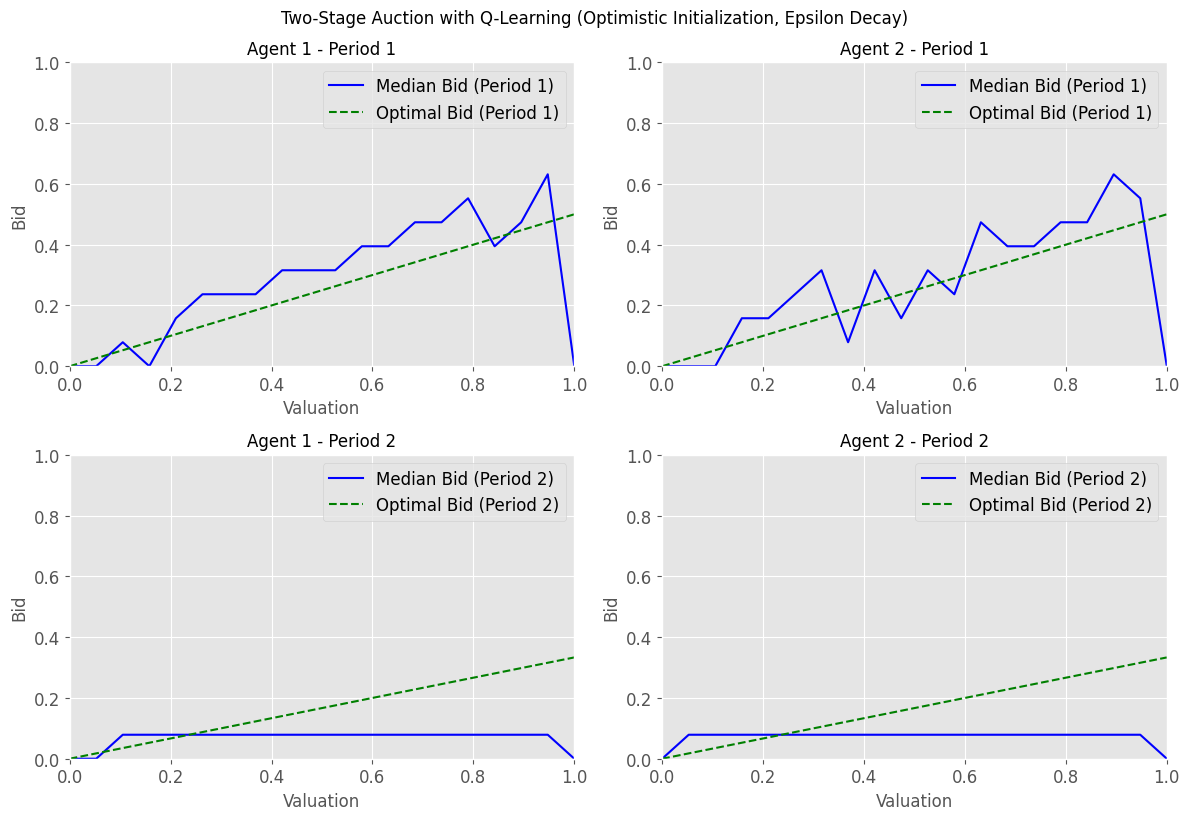

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(33454)
plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1.5, granularity=20, epsilon=0.1, epsilon_decay=1.0, alpha=0.1, min_val=0, max_val=1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay  # Added epsilon decay
        self.alpha = alpha
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        # Initialize Q-table optimistically (high values to encourage exploration)
        self.q_values = np.ones((granularity, len(self.actions), 2)) * 1.5  # Q-table for states (valuation, period)
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation, period=0)
        self.won_first_round = False  # Track if the agent won in period 1

    def get_state(self, valuation, period):
        """Return the state as a tuple (valuation index, period)"""
        valuation_state = np.digitize(valuation, np.linspace(self.min_val, self.max_val, self.granularity)) - 1
        return valuation_state, period

    def refresh_valuation(self):
        """Refresh the valuation for the new auction"""
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation, period=0)
        self.won_first_round = False  # Reset if the agent won the first round

    def choose_action(self):
        """Choose action based on epsilon-greedy strategy"""
        valuation_state, period = self.state
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[valuation_state, :, period])]

    def update_q_values(self, action, reward):
        """Update Q-values after taking an action"""
        valuation_state, period = self.state
        # Find the closest matching action
        action_index = np.argmin(np.abs(self.actions - action))
        self.q_values[valuation_state, action_index, period] += self.alpha * (reward - self.q_values[valuation_state, action_index, period])

    def feedback(self, reward, action):
        """Process feedback and update Q-values immediately"""
        self.update_q_values(action, reward)
        # Apply epsilon decay
        self.epsilon *= self.epsilon_decay  # Epsilon decay after each round


class TwoStageAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1.5, payment_rule=None, epsilon_reward=0.01):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.epsilon_reward = epsilon_reward
        self.profit_history = []

    def run_two_stage_auction(self):
        # Period 1
        for agent in self.agents:
            agent.refresh_valuation()

        bids_period1 = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]  # Removed period argument
        winner1_index, price1 = self.payment_rule(bids_period1)

        # Immediate Q-value update for Period 1
        for idx, agent in enumerate(self.agents):
            reward1 = agent.valuation - price1 + self.epsilon_reward if idx == winner1_index else 0
            agent.feedback(reward1, bids_period1[idx])
            if idx == winner1_index:
                agent.won_first_round = True  # Mark as won the first round

        # Period 2
        bids_period2 = []
        for idx, agent in enumerate(self.agents):
            agent.state = agent.get_state(agent.valuation, period=1)  # Update state to period 2
            bids_period2.append(max(self.price_floor, min(agent.choose_action(), self.price_ceiling)))

        # Ignore bids from agents who won in the first period
        for idx, agent in enumerate(self.agents):
            if agent.won_first_round:
                bids_period2[idx] = -np.inf  # Ignored bid since they can't win in period 2

        # Run auction for period 2 with all players (bids from winners are ignored)
        winner2_index, price2 = self.payment_rule(bids_period2)

        # Immediate Q-value update for Period 2
        for idx, agent in enumerate(self.agents):
            if agent.won_first_round:
                reward2 = 0  # Won first round, can't win second round
            else:
                reward2 = agent.valuation - price2 + self.epsilon_reward if idx == winner2_index else 0
            agent.feedback(reward2, bids_period2[idx])

        self.profit_history.append((price1, price2))
        return {"winner1": winner1_index, "price1": price1, "bids1": bids_period1,
                "winner2": winner2_index, "price2": price2, "bids2": bids_period2}


def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=1000):
    all_bids_for_valuations_period1 = [[] for _ in range(len(agents))]
    all_bids_for_valuations_period2 = [[] for _ in range(len(agents))]

    for sim in range(num_simulations):
        for _ in range(num_rounds):
            auction.run_two_stage_auction()

        # Average bids based on Q-values for each agent for both periods
        for i, agent in enumerate(agents):
            avg_bids_for_valuation_period1 = [agent.actions[np.argmax(agent.q_values[state, :, 0])] for state in range(agent.granularity)]
            avg_bids_for_valuation_period2 = [agent.actions[np.argmax(agent.q_values[state, :, 1])] for state in range(agent.granularity)]
            all_bids_for_valuations_period1[i].append(avg_bids_for_valuation_period1)
            all_bids_for_valuations_period2[i].append(avg_bids_for_valuation_period2)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent_period1 = np.array(all_bids_for_valuations_period1[i])
        avg_bids_for_agent_period2 = np.array(all_bids_for_valuations_period2[i])
        percentiles[i] = {
            "5th_period1": np.percentile(avg_bids_for_agent_period1, 5, axis=0),
            "median_period1": np.median(avg_bids_for_agent_period1, axis=0),
            "95th_period1": np.percentile(avg_bids_for_agent_period1, 95, axis=0),
            "5th_period2": np.percentile(avg_bids_for_agent_period2, 5, axis=0),
            "median_period2": np.median(avg_bids_for_agent_period2, axis=0),
            "95th_period2": np.percentile(avg_bids_for_agent_period2, 95, axis=0),
        }
    return percentiles


def optimal_bidding_rule(valuations, num_agents=2, period=1):
    if period == 1:
        return (num_agents - 1) / num_agents * valuations
    elif period == 2:
        return (num_agents - 1) / (num_agents + 1) * valuations

def plot_two_period_results_with_optimal(agents, percentiles, title=None, fontsize=12):
    fig, axes = plt.subplots(2, len(agents), figsize=(12, 8))  # 2 rows (for 2 periods), 2 columns (for 2 agents)
    valuations = np.linspace(0, 1, agents[0].granularity)

    for period in range(2):
        for i, agent in enumerate(agents):
            ax = axes[period, i]
            if period == 0:
                ax.fill_between(valuations, percentiles[i]["5th_period1"], percentiles[i]["95th_period1"], color='lightgray', alpha=0.5)
                ax.plot(valuations, percentiles[i]["median_period1"], label=f'Median Bid (Period 1)', color='blue')
            else:
                ax.fill_between(valuations, percentiles[i]["5th_period2"], percentiles[i]["95th_period2"], color='lightgray', alpha=0.5)
                ax.plot(valuations, percentiles[i]["median_period2"], label=f'Median Bid (Period 2)', color='blue')

            # Plot the optimal bids
            optimal_bids = optimal_bidding_rule(valuations, num_agents=len(agents), period=period+1)
            ax.plot(valuations, optimal_bids, label=f'Optimal Bid (Period {period+1})', color='green', linestyle='--')
            
            ax.set_xlim([0,1])
            ax.set_ylim([0,1])
            ax.set_xlabel('Valuation', fontsize=fontsize)
            ax.set_ylabel('Bid', fontsize=fontsize)
            ax.set_title(f'Agent {i+1} - Period {period+1}', fontsize=fontsize)
            ax.legend(fontsize=fontsize)
            ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title:
        plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()

# Running the updated simulation for the auction with Q-learning agents
agents = [QLearningAgent(epsilon_decay=0.99) for _ in range(2)]  # Two agents for the auction with epsilon decay
auction = TwoStageAuction(agents, payment_rule=first_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=1, num_rounds=20000)

# Plot the results with correct optimal bid labels
plot_two_period_results_with_optimal(agents, percentiles, title='Two-Stage Auction with Q-Learning (Optimistic Initialization, Epsilon Decay)')


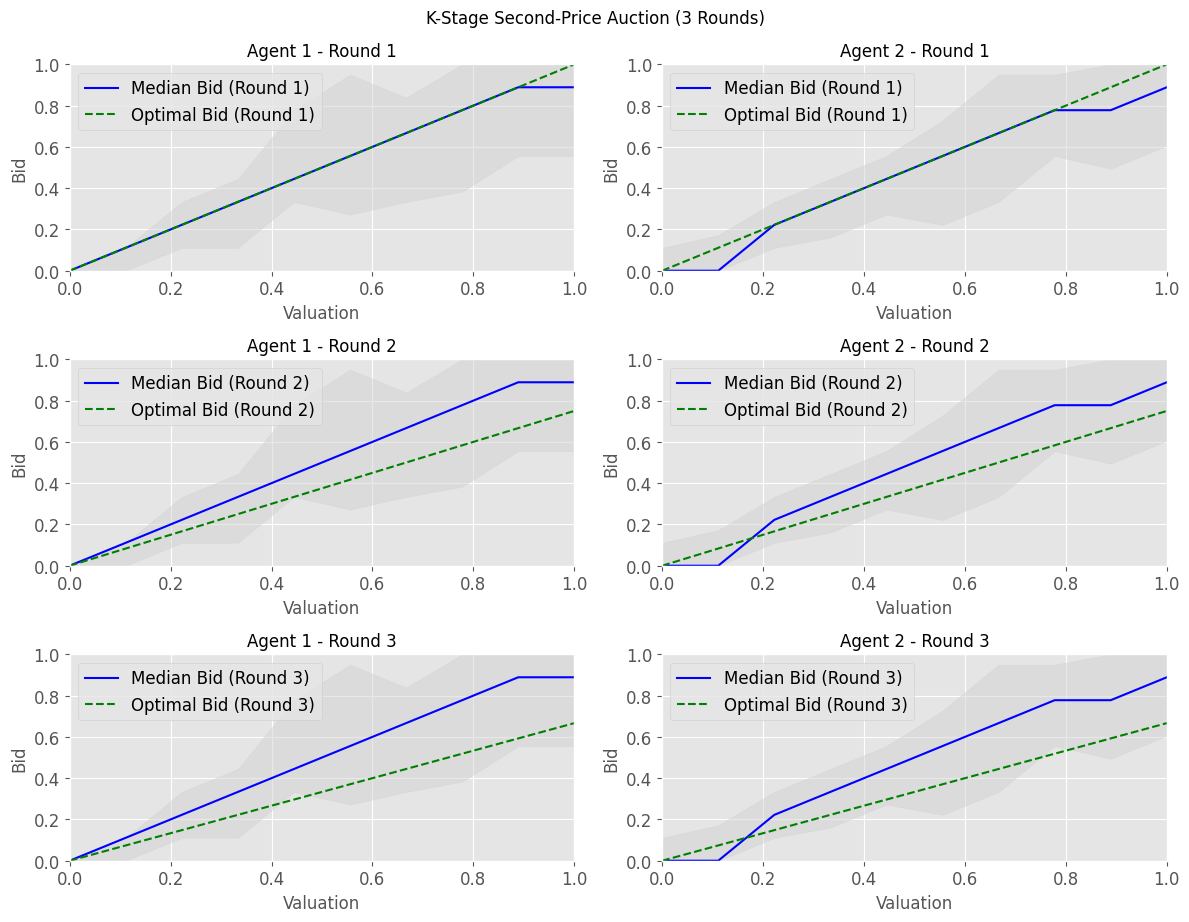

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(33454)
plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10, epsilon=0.1, alpha=0.1, min_val=0, max_val=1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))  # Q-table for the different valuation states
        self.action_counts = np.zeros((granularity, len(self.actions)))
        self.reward_history = []
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        bin_centers = np.linspace(self.min_val, self.max_val, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))

    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def choose_action(self):
        valuation_state = self.state
        return np.random.choice(self.actions) if np.random.rand() < self.epsilon else self.actions[np.argmax(self.q_values[valuation_state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)


class KStageAuction:
    def __init__(self, agents, K=3, price_floor=0, price_ceiling=1, payment_rule=None, epsilon_reward=0.001):
        self.agents = agents
        self.K = K  # Number of sequential stages
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.epsilon_reward = epsilon_reward
        self.profit_history = []

    def run_k_stage_auction(self):
        for k in range(self.K):  # Loop over K sequential auctions
            # Each agent refreshes their valuation at the start of the auction
            for agent in self.agents:
                agent.refresh_valuation()
            # Each agent chooses an action (bid)
            bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
            winner_index, payment = self.payment_rule(bids)

            # Update Q-values and rewards for each agent after each stage
            for idx, agent in enumerate(self.agents):
                reward = agent.valuation - payment + self.epsilon_reward if idx == winner_index else 0
                agent.feedback(reward, bids[idx])

            self.profit_history.append(payment)
        return {"bids": bids, "winner": winner_index, "payment": payment}


# Modified payment rule for second-price auction
def second_price_rule(bids):
    sorted_bids = np.sort(bids)
    highest_bid = sorted_bids[-1]
    second_highest_bid = sorted_bids[-2]
    
    potential_winners = np.where(bids == highest_bid)[0]
    winner = np.random.choice(potential_winners) if len(potential_winners) > 1 else potential_winners[0]
    payment = second_highest_bid  # In second-price auction, winner pays the second-highest bid
    return winner, payment


def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=1000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        for _ in range(num_rounds):
            auction.run_k_stage_auction()
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles


def plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=None, K=3, title=None, fontsize=12):
    fig, axes = plt.subplots(K, len(agents), figsize=(12, 9))  # 3 rows (for K=3), 2 columns (for 2 agents)
    valuations = np.linspace(0, 1, agents[0].granularity)

    for period in range(K):
        for i, agent in enumerate(agents):
            ax = axes[period, i]
            ax.fill_between(valuations, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
            ax.plot(valuations, percentiles[i]["median"], label=f'Median Bid (Round {period+1})', color='blue')
            
            if optimal_bid_rule:
                optimal_bids = optimal_bid_rule(valuations, K=period+1)  # Adjust optimal bid for each round
                ax.plot(valuations, optimal_bids, label=f'Optimal Bid (Round {period+1})', color='green', linestyle='--')
            
            ax.set_xlim([0,1])
            ax.set_ylim([0,1])
            ax.set_xlabel('Valuation', fontsize=fontsize)
            ax.set_ylabel('Bid', fontsize=fontsize)
            ax.set_title(f'Agent {i+1} - Round {period+1}', fontsize=fontsize)
            ax.legend(fontsize=fontsize)
            ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title:
        plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()


# Optimal bidding rule for second-price auction
def optimal_bidding_rule(valuations, K, N=5):
    # In second-price auction, last round bidding is truthful
    if K == 1:
        return valuations
    # Earlier rounds mimic the first-price auction's recursive behavior
    return (N - K) / (N - K + 1) * valuations

# Running the simulation for K=3 stages in a second-price auction
agents = [QLearningAgent() for _ in range(2)]
auction = KStageAuction(agents, K=3, payment_rule=second_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=20000)
plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=optimal_bidding_rule, K=3, title='K-Stage Second-Price Auction (3 Rounds)')